## Convert data with `pygid`

In [1]:
import pygid

exp_metadata = pygid.ExpMetadata(
    start_time = r"2025-09-09T20:36:23.076828",
    end_time    = r"2025-09-09T20:37:24.076828",
    source_type = "synchrotron",
    source_name = "ESRF ID10",
    detector = "eiger4m",
    monitor = 294302)

smpl_metadata = pygid.SampleMetadata(path_to_load="sample.yaml")

INFO - Saved in C:\Users\Asus\mlgid\mlgidBASE\example\result_from_file.h5 in group entry_0001


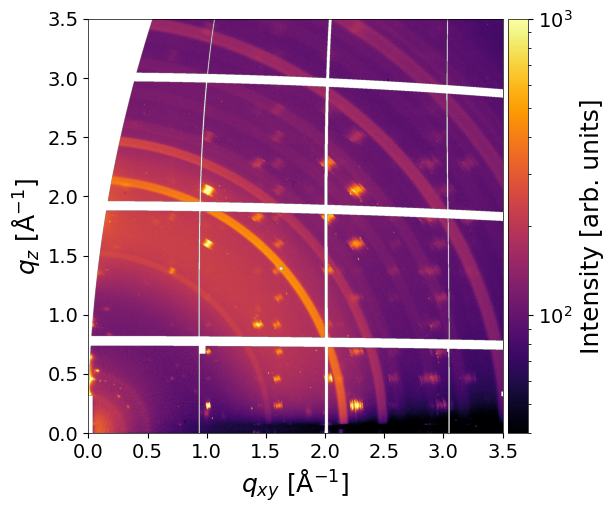

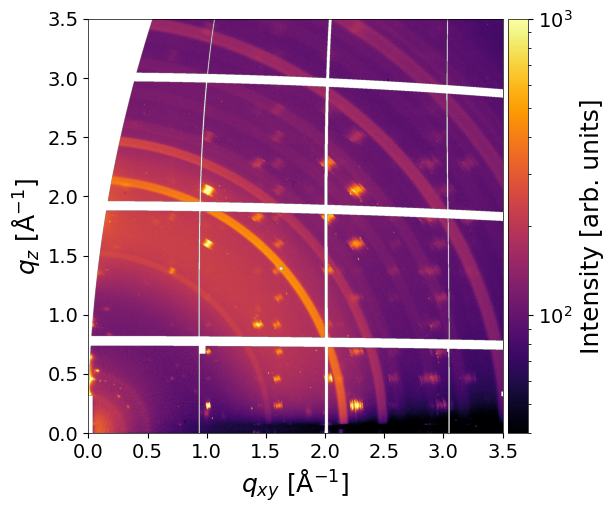

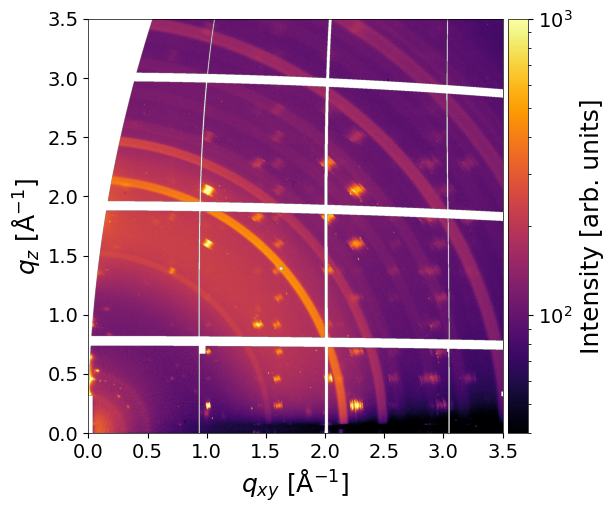

In [2]:
poni_path = './laB6_2025_09_05.poni'
mask_path = './mask.npy'
filename = './eiger4m_0000.h5'
filename = './eiger4m_0001.h5'
dataset = '/entry/data0/image'
frame_num = None

params = pygid.ExpParams(
	poni_path = poni_path,
    mask_path = mask_path,
    fliplr = True,
    flipud = True,
    # transp = False,
    ai = 0.075
)

matrix = pygid.CoordMaps(
    params,
    vert_positive = True, hor_positive = True,
    q_xy_range = (0, 3.5), q_z_range = (0, 3.5), dq = 0.002,
)

conversion = pygid.Conversion(
    matrix = matrix,
    path = filename,
    dataset = dataset,
    frame_num = frame_num
)

conversion.det2q_gid(clims = (40, 1000),
    plot_result = True, return_result = False,
    save_result = True, path_to_save = "result_from_file.h5",
    overwrite_file = False, h5_group = "entry_0001",
    overwrite_group = False,
    smpl_metadata = smpl_metadata, exp_metadata=exp_metadata
)


## From `pygid.Conversion`

In [3]:
from mlgidbase import mlgidBASE
analysis = mlgidBASE(pygid_conversion = conversion)

In [4]:
analysis.run_detection()
analysis.run_fitting()

INFO - Loading model


In [7]:
analysis.plot_analysis_results()

In [6]:
analysis.imp_detect = None
import pickle
with open('analysis.pkl', 'wb') as f:
    pickle.dump(analysis, f)

In [1]:
import pickle
with open('analysis.pkl', 'rb') as f:
    analysis = pickle.load(f)

In [5]:
analysis.run_matching(cif_prepr = r'prepr_cifs.pickle', peaks_type='segments', probability_threshold=0.9,
                      intensity_threshold=10)

INFO - Saved figure in C:\Users\Asus\mlgid\mlgidBASE\example\img.png


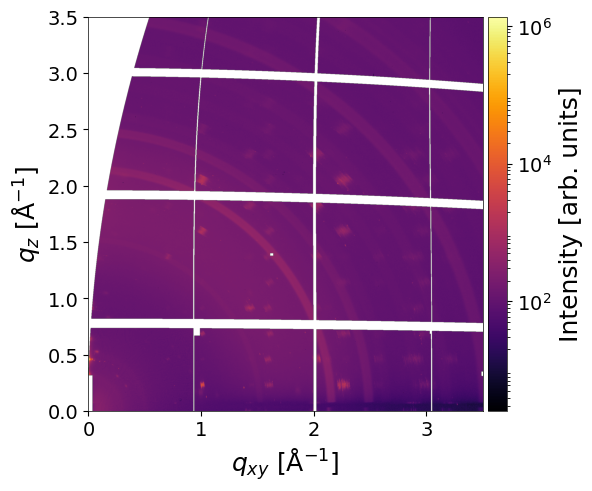

INFO - Saved figure in C:\Users\Asus\mlgid\mlgidBASE\example\img.png


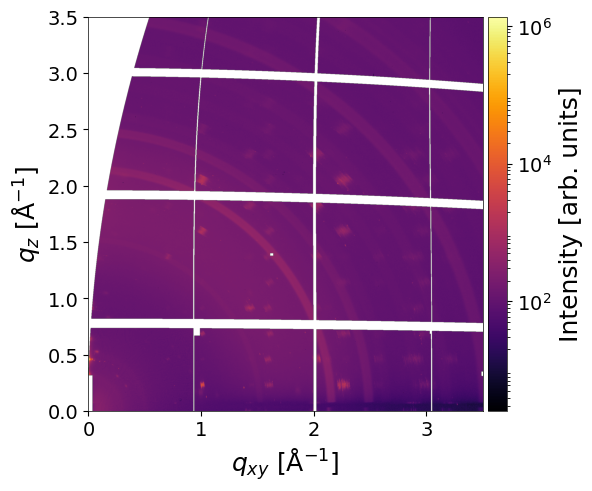

INFO - Saved figure in C:\Users\Asus\mlgid\mlgidBASE\example\img.png


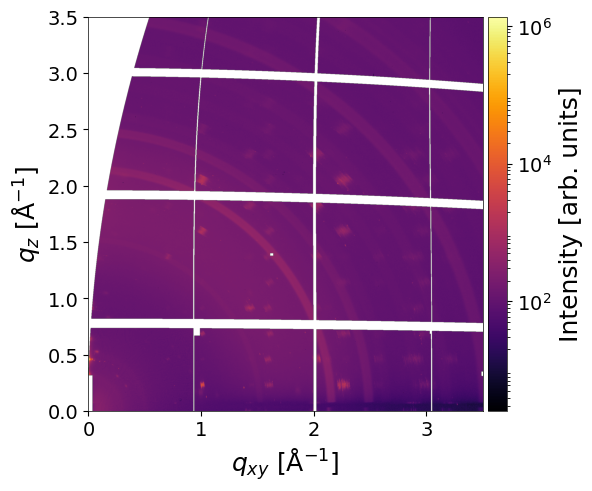

In [2]:
analysis.set_plot_defaults(savefig_dpi=200)
analysis.plot_analysis_results(save_fig = True, path_to_save_fig = 'img.png',
                               detected_params={'plot': False},
                               fitted_params={'plot': False},
                               matched_params={'plot': False})

In [ ]:
analysis.plot_analysis_results(
                              detected_params = {'line_width': 0.5,
                                               'line_style': "--",
                                               'line_color': "black",
                                               'plot': False},
                              fitted_params = {'plot_segments': True,
                                               'marker': 'o',
                                               'marker_size': 50,
                                               'marker_facecolor': "none",
                                               'marker_edgecolor': "bone",
                                               'plot_rings': True,
                                               'line_width': 1,
                                               'line_style': "--",
                                               'line_color': "bone",
                                               'plot': False},
                              matched_params = {'plot_segments': True,
                                               'marker': ['s'],
                                               'marker_size': [50],
                                               'marker_facecolor': ["none"],
                                               'marker_edgecolor': ["green", "red"],
                                               'plot_rings': True,
                                               'line_width': [1],
                                               'line_style': ["--"],
                                               'line_color': ["green"],
                                               'plot': True,
                                               'legend': True},
                              frame_num = None, entry = None,
                              return_result=False, plot_result=True,
                              clims=(50, 1e4), xlim=(None, None), ylim=(None, None),
                              save_fig=True, path_to_save_fig="img.png")

In [7]:
analysis.save_result(path_to_save='result_from_conversion.h5',
                     # smpl_metadata = smpl_metadata, exp_metadata=exp_metadata,
                     save_polar=True)

INFO - Saved in C:\Users\Asus\mlgid\mlgidBASE\example\result_from_conversion.h5 in group entry_0000
INFO - Saved in C:\Users\Asus\mlgid\mlgidBASE\example\result_from_conversion.h5 in group entry_polar_0000


## From file

In [1]:
from mlgidbase import mlgidBASE
filename = r'result_from_file.h5'
analysis = mlgidBASE(filename = filename)

In [6]:
analysis.run_detection()

INFO - Loading model
INFO - Saved detected peaks to file: result_from_file.h5, entry: entry_0000, frame: 0
INFO - Saved detected peaks to file: result_from_file.h5, entry: entry_0000, frame: 1
INFO - Saved detected peaks to file: result_from_file.h5, entry: entry_0000, frame: 2
INFO - Saved detected peaks to file: result_from_file.h5, entry: entry_0001, frame: 0


In [7]:
analysis.run_fitting()

INFO - Saved fitted peaks to file: result_from_file.h5, entry: entry_0000, frame: 0
INFO - Saved fitted peaks to file: result_from_file.h5, entry: entry_0000, frame: 1
INFO - Saved fitted peaks to file: result_from_file.h5, entry: entry_0000, frame: 2
INFO - Saved fitted peaks to file: result_from_file.h5, entry: entry_0001, frame: 0


In [2]:
# cif_prep = r'C:\Users\Asus\Downloads\WPy64-312100\notebooks\GP\prepr_cifs.pickle'
cif_prep = r'prepr_cifs.pickle'
analysis.run_matching(cif_prepr = cif_prep, peaks_type='rings', threshold=0.9)

INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 0
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 1
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 2
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0001, frame: 0


In [3]:
cif_prep = r'prepr_cifs.pickle'
analysis.run_matching(cif_prepr = cif_prep, peaks_type='segments', threshold=0.9)

INFO - cif_prepr is already set. The previous cif_prepr is to be used
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 0
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 1
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0000, frame: 2
INFO - Saved matched peaks to file: result_from_file.h5, entry: entry_0001, frame: 0


INFO - Saved figure in C:\Users\Asus\mlgid\mlgidBASE\example\img_entry_0001_fr_0000_sol_0000.png


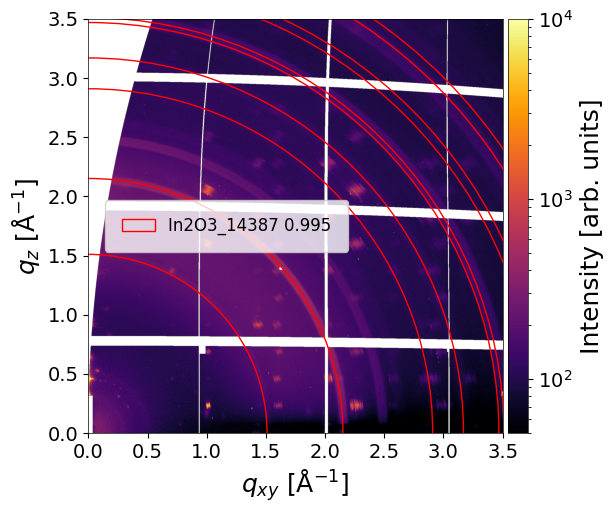

INFO - Saved figure in C:\Users\Asus\mlgid\mlgidBASE\example\img_entry_0001_fr_0000_sol_0001.png


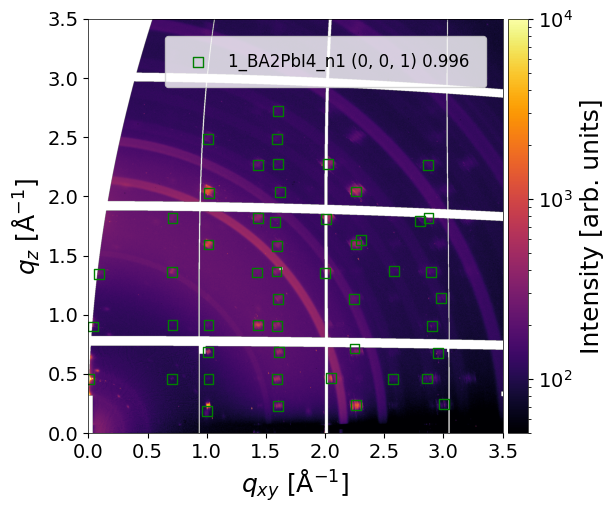

In [2]:
from mlgidbase import mlgidBASE
filename = r'result_from_file.h5'
analysis = mlgidBASE(filename = filename)
analysis.plot_analysis_results(
                              detected_params = {'line_width': 0.5,
                                               'line_style': "--",
                                               'line_color': "black",
                                               'plot': False},
                              fitted_params = {'plot_segments': True,
                                               'marker': 'o',
                                               'marker_size': 50,
                                               'marker_facecolor': "none",
                                               'marker_edgecolor': "bone",
                                               'plot_rings': True,
                                               'line_width': 1,
                                               'line_style': "--",
                                               'line_color': "bone",
                                               'plot': False,
                                               'intensity_threshold': 0},
                              matched_params = {'plot_segments': True,
                                               'marker': ['s'],
                                               'marker_size': [50],
                                               'marker_facecolor': ["none"],
                                               'marker_edgecolor': ["green", "red"],
                                               'plot_rings': True,
                                               'line_width': [1],
                                               'line_style': ["-", "--"],
                                               'line_color': ["red", "green"],
                                               'plot': True,
                                               'legend': True,
                                                'probability_threshold': 0},
                              frame_num = 0, entry = 'entry_0001',
                              return_result=False, plot_result=True,
                              clims=(50, 1e4), xlim=(None, None), ylim=(None, None),
                              save_fig=True, path_to_save_fig="img.png")

In [18]:
# peak_idx = peak_idx[amp[peak_idx]>intensity_threshold]
import numpy as np
intensity_threshold = 1
amp = np.array([0,0,0, 1,2,3,4,5,6,7])
peak_idx = [0,2,3,4,5,6]
peak_idx = [i for i in peak_idx if amp[i]>intensity_threshold
            ]
peak_idx

[4, 5, 6]

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from matplotlib.colors import LogNorm
import os

from pathlib import Path
import h5py, numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Arc

def _plot_fitted(ax, g):
    peaks = g["fitted_peaks"]
    qxy, qz = np.array(peaks["q_xy"]), np.array(peaks["q_z"])
    amp, rad, rings = map(np.array, (peaks["amplitude"], peaks["radius"], peaks["is_ring"]))

    # scatter non-rings
    mask = ~rings
    if mask.any():
        norm = LogNorm(vmin=max(amp[mask].min(), 1e-3), vmax=amp[mask].max())
        cmap = plt.get_cmap("bone")
        colors = cmap(norm(amp[mask]))  # RGBA colors for edges

        ax.scatter(
            qxy[mask],
            qz[mask],
            facecolors='none',  # hollow inside
            edgecolors=colors,  # color rings according to amp
            marker='o',
            s=50,
            label='fitted'
        )
        # ax.scatter(qxy[mask], qz[mask], c=amp[mask], cmap="bone", facecolor = None,#edgecolors='black',
        #            norm=LogNorm(vmin=max(amp[mask].min(), 1e-3), vmax=amp[mask].max()),
                   # marker="o", s=50, label="fitted")

    # draw rings
    for r, a in zip(rad[rings], amp[rings]):
        ax.add_patch(Arc((0, 0), 2*r, 2*r, theta1=0, theta2=90,
                         color=plt.cm.bone(np.log10(max(a,1e-3))/np.log10(amp[rings].max())),
                         lw=1, ls="--"))

def _plot_detected(ax, g):
    peaks = g["detected_peaks"]
    amp, rad, radw, ang, angw = (np.array(peaks[k]) for k in
                                 ["amplitude","radius","radius_width","angle","angle_width"])
    for r, dr, a, da in zip(rad, radw, ang, angw):
        for sign in (-1, +1):
            ax.add_patch(Arc((0,0), 2*(r+sign*dr), 2*(r+sign*dr),
                             theta1=a-da, theta2=a+da, lw=0.5, ls="--"))


def plot_mlgid_result_from_file(filename, vmin=1, vmax=100, fonts=14):
    filename = Path(filename)
    with h5py.File(filename, "r", locking = False) as hf:
        for entry_name, entry in hf.items():
            if "data" not in entry:
                continue
            data = entry["data"]
            if not all(k in data for k in ["img_gid_q","q_xy","q_z"]):
                continue

            img_gid_q, q_xy, q_z = map(np.array, (data["img_gid_q"], data["q_xy"], data["q_z"]))
            for i, frame in enumerate(img_gid_q):
                fig, ax = plt.subplots(figsize = (5,15))
                im = ax.imshow(frame, cmap="inferno", norm=LogNorm(vmin=vmin, vmax=vmax),
                               origin="lower", extent=[q_xy.min(), q_xy.max(), q_z.min(), q_z.max()],
                               aspect="equal")
                ax.set(xlim=(0,q_xy.max()), ylim=(0,q_z.max()),
                       xlabel=r"$q_{xy}$, $\mathrm{[\AA^{-1}]}$", ylabel=r"$q_{z}$, $\mathrm{[\AA^{-1}]}$")
                ax.tick_params(labelsize=fonts)
                ax.xaxis.label.set_size(fonts*1.5)
                ax.yaxis.label.set_size(fonts*1.5)
                # plt.colorbar(im, ax=ax, label="Intensity (a.u.)")

                gpath = f"{entry_name}/data/analysis/frame{i:05d}"
                if gpath in hf:
                    g = hf[gpath]
                    if "fitted_peaks" in g: _plot_fitted(ax, g)
                    if "detected_peaks" in g: _plot_detected(ax, g)

                # plt.savefig(output_dir / f"{sample}_{entry_name}_{i:04d}.png", dpi=400)
                # plt.close()
                break



%matplotlib inline
filename = './result_from_conversion.h5'
filename = './result_from_file.h5'
plot_mlgid_result_from_file(filename, vmin=40, vmax=1000)
plt.show()